# ETL Base de dados de Vendas

1. Carregar o arquivo vendas_5000_linhas e identificar o problema que existe em uma de suas colunas.

2. Conserte o erro da coluna identificada.

3. Produzir a coluna Total da Venda (preco * quantidade)

4. Produzir as colunas "Imposto Pago" e a coluna "Taxa de Pagamento"

5. **Regra coluna "Imposto Pago"**

    - Acessórios -> 10% do total da venda
    - Eletrônicos -> 7.5% do total da venda
    - Móveis e Outros -> 5% do total da venda

6. **Regra coluna "Taxa de Pagamento":**

    - Débito ou crédito -> 5% do total da venda
    - Boleto -> 2.5% do total da venda
    - Pix e outros -> 0% do total da venda

7. Produzir a coluna Lucro Total. (Soma da receitas - Soma das despesas)

8. Exportar dados resultantes para arquivo excel ou csv

# Carregamento e Diagnóstico

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("vendas_5000_linhas.csv")

display(df.head(10))
display(df.info())
display(df.dtypes)
display(df.columns)
display(df.duplicated().sum())

,data_venda,cliente,loja,produto,categoria,quantidade,preco_unitario,custo_unitario,cidade,estado,regiao,forma_pagamento
0,2023-04-15,Cliente 174,Loja Oeste,Mouse,Eletrônicos,5,894.88,484.90,São Paulo,SP,sudeste,Boleto
1,2023-01-28,Cliente 144,Loja Norte,Notebook,Eletrônicos,2,804.30,524.09,São Paulo,SP,centro-oeste,Boleto
2,2023-06-13,Cliente 179,Loja Leste,Monitor,Eletrônicos,10,1009.76,768.22,Fortaleza,CE,Nordeste,Pix
3,2024-01-03,Cliente 89,Loja Oeste,Teclado,Eletrônicos,6,402.63,247.21,Curitiba,PR,SUL,Crédito
4,2024-07-19,Cliente 76,Loja Oeste,Celular,Eletrônicos,2,3407.25,2090.55,Brasília,DF,Nordeste,Débito
5,2023-08-27,Cliente 26,Loja Leste,Mouse,Eletrônicos,4,2717.09,2161.63,São Paulo,SP,SUL,Boleto
6,2024-12-19,Cliente 175,Loja Centro,Mesa,Móveis,6,1275.68,894.32,Belo Horizonte,MG,CENTRO-OESTE,Débito
7,2024-10-17,Cliente 177,Loja Oeste,Fone de Ouvido,Acessórios,3,1644.80,955.60,Curitiba,PR,Sul,Pix
8,2023-03-09,Cliente 55,Loja Oeste,Notebook,Eletrônicos,1,2827.41,1753.98,Curitiba,PR,Nordeste,Débito
9,2024-07-28,Cliente 138,Loja Sul,Celular,Eletrônicos,8,542.91,294.20,Recife,PE,CENTRO-OESTE,Boleto


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   data_venda       5000 non-null   object 
 1   cliente          5000 non-null   object 
 2   loja             5000 non-null   object 
 3   produto          5000 non-null   object 
 4   categoria        5000 non-null   object 
 5   quantidade       5000 non-null   int64  
 6   preco_unitario   5000 non-null   float64
 7   custo_unitario   5000 non-null   float64
 8   cidade           5000 non-null   object 
 9   estado           5000 non-null   object 
 10  regiao           5000 non-null   object 
 11  forma_pagamento  5000 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 468.9+ KB


None

data_venda          object
cliente             object
loja                object
produto             object
categoria           object
quantidade           int64
preco_unitario     float64
custo_unitario     float64
cidade              object
estado              object
regiao              object
forma_pagamento     object
dtype: object

Index(['data_venda', 'cliente', 'loja', 'produto', 'categoria', 'quantidade',
       'preco_unitario', 'custo_unitario', 'cidade', 'estado', 'regiao',
       'forma_pagamento'],
      dtype='object')

np.int64(0)

## Correção de Tipos e Ajuste da Coluna Região

In [3]:
df[["cliente", "loja", "produto", "categoria", "cidade", "estado", "regiao", "forma_pagamento"]] = df[["cliente", "loja", "produto", "categoria", "cidade", "estado", "regiao", "forma_pagamento"]].astype("string")

df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")

df["regiao"] = df["regiao"].str.title()


## Enriquecimento dos Dados

### Coluna Total Venda

In [4]:
df["total_venda"] = df["preco_unitario"] * df["quantidade"]

### Coluna Imposto Pago

In [5]:
# Método mais elegante
# def classificar_imposto(linha):
    
#     if linha["categoria"] == "Acessórios":
#         return linha["total_venda"] * 0.1
#     elif linha["categoria"] == "Eletrônicos":
#         return linha["total_venda"] * 0.075
#     else:
#         return linha["total_venda"] * 0.05

# df["imposto_pago"] = df.apply(classificar_imposto, axis=1).round(2)

# Método intermediário
def classificar_imposto(categoria):
    if categoria == "Acessórios":
        return 0.1
    elif categoria == "Eletrônicos":
        return 0.075
    else:
        return 0.05

df["imposto_porcentagem"] = df["categoria"].apply(classificar_imposto)
df["imposto_pago"] = df["total_venda"] * df["imposto_porcentagem"]
df["imposto_pago"] = df["imposto_pago"].round(2)


# Usando loc de maneira manual

# df["imposto_pago"] = df["total_venda"] * 0.05
# df.loc[df["categoria"] == "Acessório", "imposto_pago"] = df["total_venda"] * 0.1
# df.loc[df["categoria"] == "Eletrônicos", "imposto_pago"] = df["total_venda"] * 0.075

display(df.head(10))

,data_venda,cliente,loja,produto,categoria,quantidade,preco_unitario,custo_unitario,cidade,estado,regiao,forma_pagamento,total_venda,imposto_porcentagem,imposto_pago
0,2023-04-15,Cliente 174,Loja Oeste,Mouse,Eletrônicos,5,894.88,484.90,São Paulo,SP,Sudeste,Boleto,4474.40,0.075,335.58
1,2023-01-28,Cliente 144,Loja Norte,Notebook,Eletrônicos,2,804.30,524.09,São Paulo,SP,Centro-Oeste,Boleto,1608.60,0.075,120.64
2,2023-06-13,Cliente 179,Loja Leste,Monitor,Eletrônicos,10,1009.76,768.22,Fortaleza,CE,Nordeste,Pix,10097.60,0.075,757.32
3,2024-01-03,Cliente 89,Loja Oeste,Teclado,Eletrônicos,6,402.63,247.21,Curitiba,PR,Sul,Crédito,2415.78,0.075,181.18
4,2024-07-19,Cliente 76,Loja Oeste,Celular,Eletrônicos,2,3407.25,2090.55,Brasília,DF,Nordeste,Débito,6814.50,0.075,511.09
5,2023-08-27,Cliente 26,Loja Leste,Mouse,Eletrônicos,4,2717.09,2161.63,São Paulo,SP,Sul,Boleto,10868.36,0.075,815.13
6,2024-12-19,Cliente 175,Loja Centro,Mesa,Móveis,6,1275.68,894.32,Belo Horizonte,MG,Centro-Oeste,Débito,7654.08,0.050,382.70
7,2024-10-17,Cliente 177,Loja Oeste,Fone de Ouvido,Acessórios,3,1644.80,955.60,Curitiba,PR,Sul,Pix,4934.40,0.100,493.44
8,2023-03-09,Cliente 55,Loja Oeste,Notebook,Eletrônicos,1,2827.41,1753.98,Curitiba,PR,Nordeste,Débito,2827.41,0.075,212.06
9,2024-07-28,Cliente 138,Loja Sul,Celular,Eletrônicos,8,542.91,294.20,Recife,PE,Centro-Oeste,Boleto,4343.28,0.075,325.75


### Coluna Taxa de Pagamento

In [6]:
def classificar_pagamento(forma_pagamento):
    if forma_pagamento == "Crédito" or forma_pagamento == "Débito":
        return 0.05
    elif forma_pagamento == "Boleto":
        return 0.025
    elif forma_pagamento == "Pix":
        return 0
    else:
        pd.NA


df["taxa_pagamento_porcentagem"] = df["forma_pagamento"].apply(classificar_pagamento)
df["taxa_pagamento_pago"] = df["total_venda"] * df["taxa_pagamento_porcentagem"]
df["taxa_pagamento_pago"] = df["taxa_pagamento_pago"].round(2)

### Coluna Custo do Produto

In [7]:
df["custo_produtos"] = df["quantidade"] * df["custo_unitario"]

### Coluna Custo da Venda

In [8]:
df["custo_venda"] = df["custo_produtos"] + df["imposto_pago"] + df["taxa_pagamento_pago"]

### Coluna Lucro da Venda

In [9]:
df["lucro_venda"] = df["total_venda"] - df["custo_venda"]

In [12]:
# LUCRO POR LOJA TRATADO VALOR MOEDA

lucro_por_loja = df.groupby("loja")["lucro_venda"].sum().reset_index().sort_values(by="lucro_venda", ascending=False)  
lucro_por_loja["lucro_venda"] = lucro_por_loja["lucro_venda"].apply(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
display(lucro_por_loja)


,loja,lucro_venda
1,Loja Leste,"R$ 2.449.135,86"
2,Loja Norte,"R$ 2.428.764,69"
3,Loja Oeste,"R$ 2.392.751,99"
4,Loja Sul,"R$ 2.349.799,68"
0,Loja Centro,"R$ 2.249.140,90"


In [13]:
# FORMAS DE PAGAMENTO MAIS USADAS
formas_pagamento = df["forma_pagamento"].value_counts().reset_index()
formas_pagamento.columns = ["forma_pagamento", "quantidade"]
display(formas_pagamento)

,forma_pagamento,quantidade
0,Boleto,1314
1,Débito,1245
2,Crédito,1231
3,Pix,1210


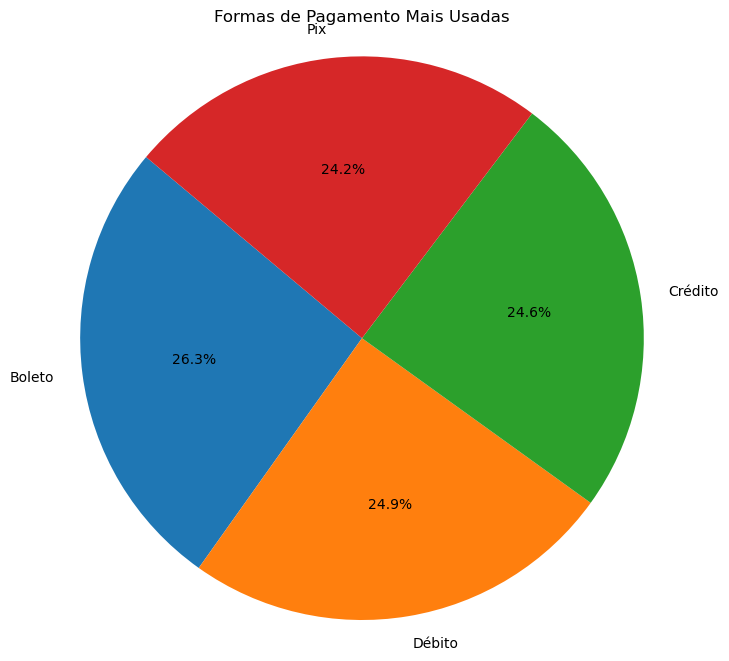

In [15]:
# GRAFICO PIZZA FORMAS DE PAGAMENTO

plt.figure(figsize=(8, 8))
plt.pie(formas_pagamento["quantidade"], labels=formas_pagamento["forma_pagamento"], autopct="%1.1f%%", startangle=140)
plt.title("Formas de Pagamento Mais Usadas")    
plt.axis("equal")
plt.show()


In [18]:
# COLUNA FATURAMNETO
df["faturamento"] = df["total_venda"] - df["imposto_pago"]
df["faturamento"] = df["faturamento"].round(2)  
display(df.head(10))

,data_venda,cliente,loja,produto,categoria,quantidade,preco_unitario,custo_unitario,cidade,estado,...,forma_pagamento,total_venda,imposto_porcentagem,imposto_pago,taxa_pagamento_porcentagem,taxa_pagamento_pago,custo_produtos,custo_venda,lucro_venda,faturamento
0,2023-04-15,Cliente 174,Loja Oeste,Mouse,Eletrônicos,5,894.88,484.90,São Paulo,SP,...,Boleto,4474.40,0.075,335.58,0.025,111.86,2424.50,2871.94,1602.46,4138.82
1,2023-01-28,Cliente 144,Loja Norte,Notebook,Eletrônicos,2,804.30,524.09,São Paulo,SP,...,Boleto,1608.60,0.075,120.64,0.025,40.22,1048.18,1209.04,399.56,1487.96
2,2023-06-13,Cliente 179,Loja Leste,Monitor,Eletrônicos,10,1009.76,768.22,Fortaleza,CE,...,Pix,10097.60,0.075,757.32,0.000,0.00,7682.20,8439.52,1658.08,9340.28
3,2024-01-03,Cliente 89,Loja Oeste,Teclado,Eletrônicos,6,402.63,247.21,Curitiba,PR,...,Crédito,2415.78,0.075,181.18,0.050,120.79,1483.26,1785.23,630.55,2234.60
4,2024-07-19,Cliente 76,Loja Oeste,Celular,Eletrônicos,2,3407.25,2090.55,Brasília,DF,...,Débito,6814.50,0.075,511.09,0.050,340.72,4181.10,5032.91,1781.59,6303.41
5,2023-08-27,Cliente 26,Loja Leste,Mouse,Eletrônicos,4,2717.09,2161.63,São Paulo,SP,...,Boleto,10868.36,0.075,815.13,0.025,271.71,8646.52,9733.36,1135.00,10053.23
6,2024-12-19,Cliente 175,Loja Centro,Mesa,Móveis,6,1275.68,894.32,Belo Horizonte,MG,...,Débito,7654.08,0.050,382.70,0.050,382.70,5365.92,6131.32,1522.76,7271.38
7,2024-10-17,Cliente 177,Loja Oeste,Fone de Ouvido,Acessórios,3,1644.80,955.60,Curitiba,PR,...,Pix,4934.40,0.100,493.44,0.000,0.00,2866.80,3360.24,1574.16,4440.96
8,2023-03-09,Cliente 55,Loja Oeste,Notebook,Eletrônicos,1,2827.41,1753.98,Curitiba,PR,...,Débito,2827.41,0.075,212.06,0.050,141.37,1753.98,2107.41,720.00,2615.35
9,2024-07-28,Cliente 138,Loja Sul,Celular,Eletrônicos,8,542.91,294.20,Recife,PE,...,Boleto,4343.28,0.075,325.75,0.025,108.58,2353.60,2787.93,1555.35,4017.53


In [19]:
# Top 8 Produtos por Faturamento
top_8_produtos = df.groupby("produto")["faturamento"].sum().reset_index().sort_values(by="faturamento", ascending=False).head(8)
top_8_produtos["faturamento"] = top_8_produtos["faturamento"].apply(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
display(top_8_produtos)

,produto,faturamento
3,Impressora,"R$ 4.911.617,00"
8,Teclado,"R$ 4.766.630,24"
1,Celular,"R$ 4.644.728,75"
4,Mesa,"R$ 4.636.763,03"
0,Cadeira,"R$ 4.455.226,07"
6,Mouse,"R$ 4.429.534,99"
9,Webcam,"R$ 4.318.691,78"
5,Monitor,"R$ 4.284.283,87"


# Exportação dos Dados

In [10]:
display(df.head(10))
display(df.info())
display(df[["total_venda", "imposto_pago", "taxa_pagamento_pago","custo_venda","lucro_venda"]].describe())

df.to_csv("vendas_5000_linhas_tratado.csv")

,data_venda,cliente,loja,produto,categoria,quantidade,preco_unitario,custo_unitario,cidade,estado,regiao,forma_pagamento,total_venda,imposto_porcentagem,imposto_pago,taxa_pagamento_porcentagem,taxa_pagamento_pago,custo_produtos,custo_venda,lucro_venda
0,2023-04-15,Cliente 174,Loja Oeste,Mouse,Eletrônicos,5,894.88,484.90,São Paulo,SP,Sudeste,Boleto,4474.40,0.075,335.58,0.025,111.86,2424.50,2871.94,1602.46
1,2023-01-28,Cliente 144,Loja Norte,Notebook,Eletrônicos,2,804.30,524.09,São Paulo,SP,Centro-Oeste,Boleto,1608.60,0.075,120.64,0.025,40.22,1048.18,1209.04,399.56
2,2023-06-13,Cliente 179,Loja Leste,Monitor,Eletrônicos,10,1009.76,768.22,Fortaleza,CE,Nordeste,Pix,10097.60,0.075,757.32,0.000,0.00,7682.20,8439.52,1658.08
3,2024-01-03,Cliente 89,Loja Oeste,Teclado,Eletrônicos,6,402.63,247.21,Curitiba,PR,Sul,Crédito,2415.78,0.075,181.18,0.050,120.79,1483.26,1785.23,630.55
4,2024-07-19,Cliente 76,Loja Oeste,Celular,Eletrônicos,2,3407.25,2090.55,Brasília,DF,Nordeste,Débito,6814.50,0.075,511.09,0.050,340.72,4181.10,5032.91,1781.59
5,2023-08-27,Cliente 26,Loja Leste,Mouse,Eletrônicos,4,2717.09,2161.63,São Paulo,SP,Sul,Boleto,10868.36,0.075,815.13,0.025,271.71,8646.52,9733.36,1135.00
6,2024-12-19,Cliente 175,Loja Centro,Mesa,Móveis,6,1275.68,894.32,Belo Horizonte,MG,Centro-Oeste,Débito,7654.08,0.050,382.70,0.050,382.70,5365.92,6131.32,1522.76
7,2024-10-17,Cliente 177,Loja Oeste,Fone de Ouvido,Acessórios,3,1644.80,955.60,Curitiba,PR,Sul,Pix,4934.40,0.100,493.44,0.000,0.00,2866.80,3360.24,1574.16
8,2023-03-09,Cliente 55,Loja Oeste,Notebook,Eletrônicos,1,2827.41,1753.98,Curitiba,PR,Nordeste,Débito,2827.41,0.075,212.06,0.050,141.37,1753.98,2107.41,720.00
9,2024-07-28,Cliente 138,Loja Sul,Celular,Eletrônicos,8,542.91,294.20,Recife,PE,Centro-Oeste,Boleto,4343.28,0.075,325.75,0.025,108.58,2353.60,2787.93,1555.35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   data_venda                  5000 non-null   datetime64[ns]
 1   cliente                     5000 non-null   string        
 2   loja                        5000 non-null   string        
 3   produto                     5000 non-null   string        
 4   categoria                   5000 non-null   string        
 5   quantidade                  5000 non-null   int64         
 6   preco_unitario              5000 non-null   float64       
 7   custo_unitario              5000 non-null   float64       
 8   cidade                      5000 non-null   string        
 9   estado                      5000 non-null   string        
 10  regiao                      5000 non-null   string        
 11  forma_pagamento             5000 non-null   string      

None

,total_venda,imposto_pago,taxa_pagamento_pago,custo_venda,lucro_venda
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,9683.523480,725.201164,301.631970,7309.604856,2373.918624
std,8001.642637,629.658992,356.250763,6126.075979,2291.790556
min,52.910000,2.650000,0.000000,40.640000,8.260000
25%,3034.800000,221.642500,10.637500,2243.972500,659.070000
50%,7371.515000,541.445000,167.000000,5599.900000,1609.885000
75%,14615.545000,1071.607500,466.565000,11097.530000,3366.897500
max,34860.800000,3246.690000,1743.040000,31454.340000,14285.500000
